In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path("../data/processed")

# 读取所有数据
results = pd.read_csv(PROCESSED / "backtest_results.csv", index_col=0, parse_dates=True)
factors = pd.read_csv(PROCESSED / "ff_factors.csv", index_col=0, parse_dates=True)
cumulative = pd.read_csv(PROCESSED / "cumulative_returns.csv", index_col=0, parse_dates=True)

# 计算benchmark累计收益（市场因子 + 无风险利率）
common = results.index.intersection(factors.index)
mkt_returns = factors.loc[common, "Mkt-RF"] + factors.loc[common, "RF"]
mkt_cumulative = (1 + mkt_returns).cumprod()

print("数据加载完成")
print(f"回测区间: {results.index[0].strftime('%Y-%m')} → {results.index[-1].strftime('%Y-%m')}")

数据加载完成
回测区间: 2016-03 → 2024-12


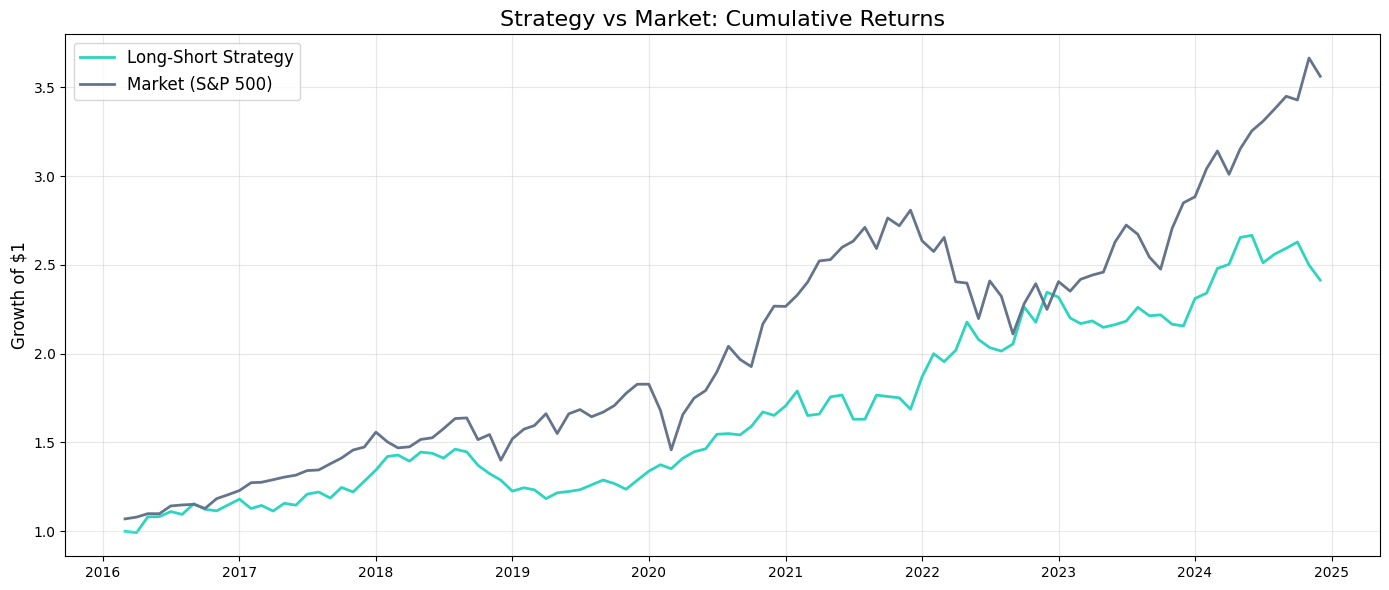

In [2]:
# 图1：策略 vs 市场 累计收益曲线
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(cumulative.index, cumulative.values, linewidth=2, color="#2dd4bf", label="Long-Short Strategy")
ax.plot(mkt_cumulative.index, mkt_cumulative.values, linewidth=2, color="#64748b", label="Market (S&P 500)")

ax.set_title("Strategy vs Market: Cumulative Returns", fontsize=16)
ax.set_ylabel("Growth of $1", fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(y=1, color="white", linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

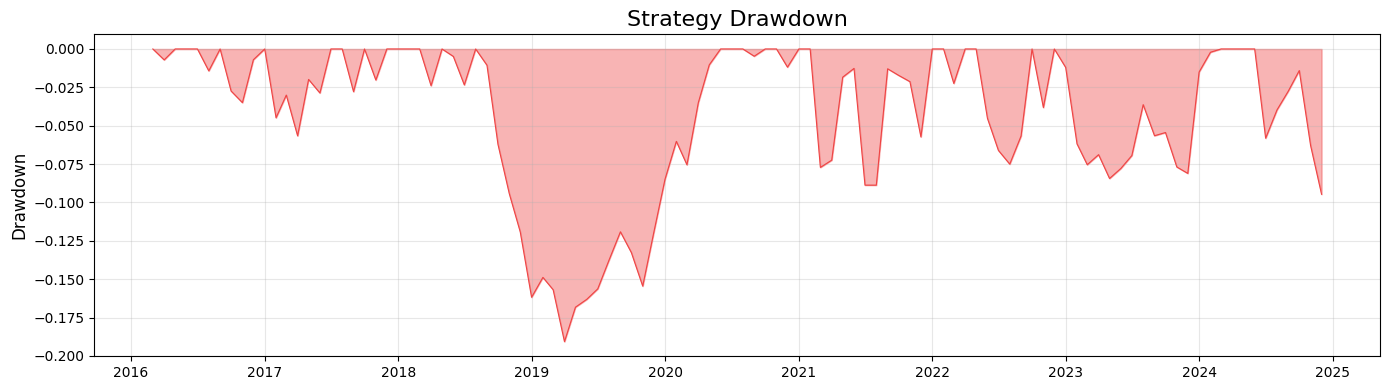

最大回撤: -19.07%，发生在 2019-04


In [3]:
# 图2：回撤曲线
port_cumulative = (1 + results["portfolio_return"]).cumprod()
rolling_max = port_cumulative.cummax()
drawdown = (port_cumulative - rolling_max) / rolling_max

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(drawdown.index, drawdown.values, 0, color="#ef4444", alpha=0.4)
ax.plot(drawdown.index, drawdown.values, color="#ef4444", linewidth=0.8)
ax.set_title("Strategy Drawdown", fontsize=16)
ax.set_ylabel("Drawdown", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 找最大回撤的时间
worst_date = drawdown.idxmin()
print(f"最大回撤: {drawdown.min():.2%}，发生在 {worst_date.strftime('%Y-%m')}")

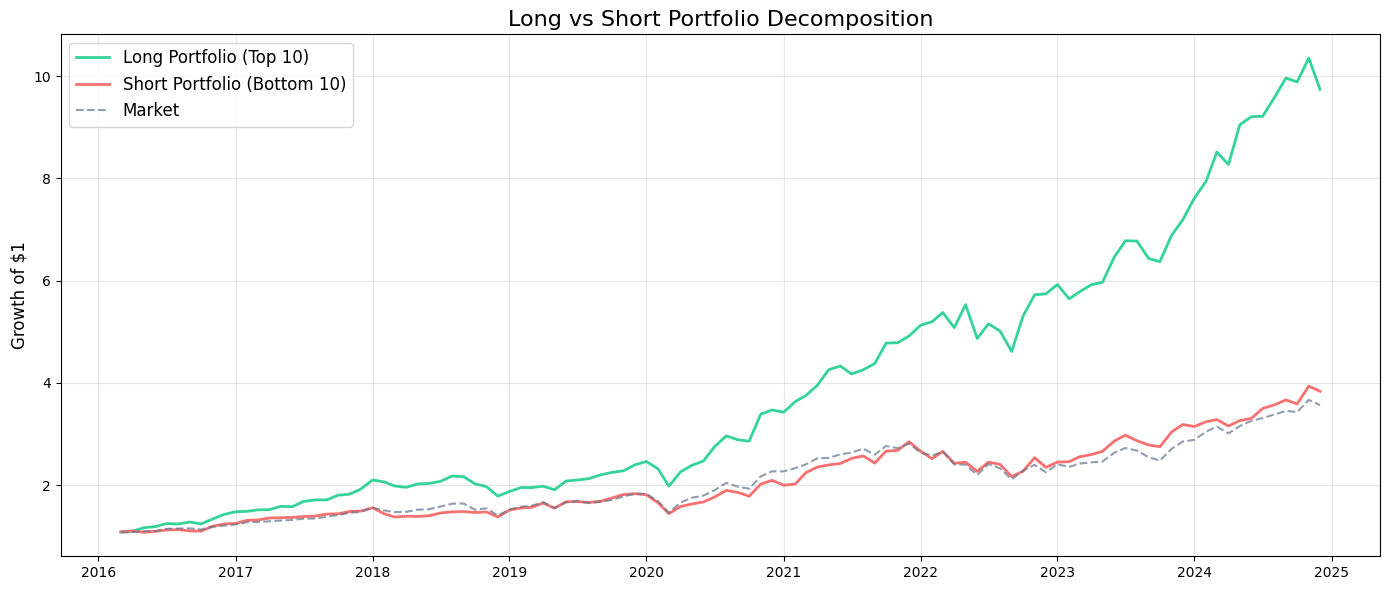

做多端终值: $9.74
做空端终值: $3.83
市场终值: $3.56


In [4]:
# 图3：做多端 vs 做空端 累计收益
long_cum = (1 + results["long_return"]).cumprod()
short_cum = (1 + results["short_return"]).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(long_cum.index, long_cum.values, linewidth=2, color="#34d399", label="Long Portfolio (Top 10)")
ax.plot(short_cum.index, short_cum.values, linewidth=2, color="#f87171", label="Short Portfolio (Bottom 10)")
ax.plot(mkt_cumulative.index, mkt_cumulative.values, linewidth=1.5, color="#64748b", linestyle="--", label="Market", alpha=0.7)

ax.set_title("Long vs Short Portfolio Decomposition", fontsize=16)
ax.set_ylabel("Growth of $1", fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"做多端终值: ${long_cum.iloc[-1]:.2f}")
print(f"做空端终值: ${short_cum.iloc[-1]:.2f}")
print(f"市场终值: ${mkt_cumulative.iloc[-1]:.2f}")

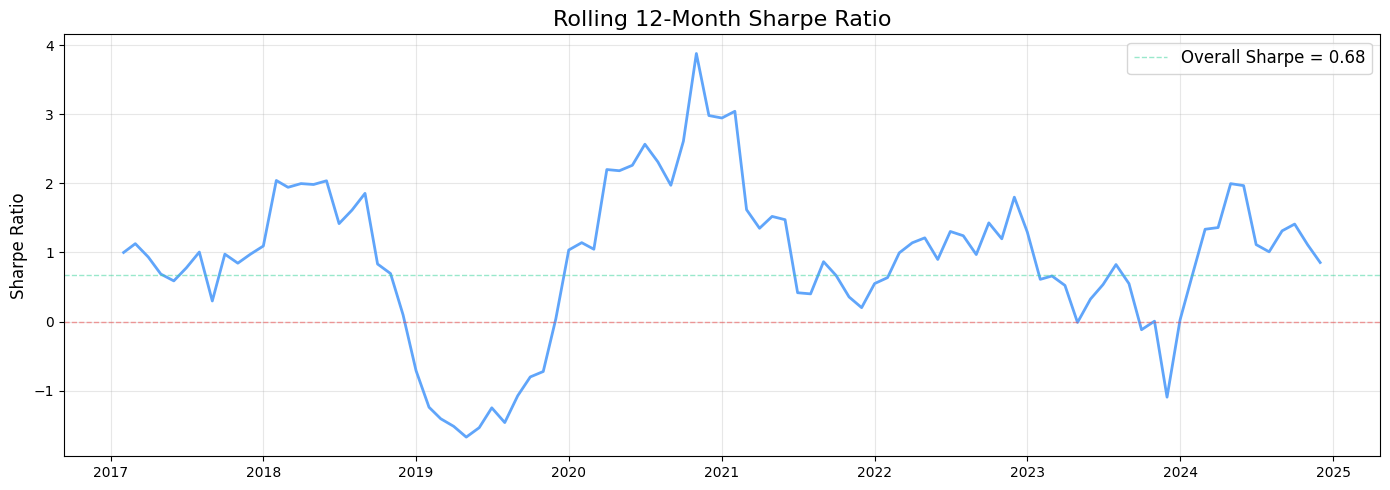

Sharpe为负的月数: 14/95 (14.7%)


In [5]:
# 图4：12个月滚动Sharpe Ratio
rolling_mean = results["portfolio_return"].rolling(12).mean()
rolling_std = results["portfolio_return"].rolling(12).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(12)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=2, color="#60a5fa")
ax.axhline(y=0, color="#ef4444", linewidth=1, linestyle="--", alpha=0.5)
ax.axhline(y=0.68, color="#34d399", linewidth=1, linestyle="--", alpha=0.5, label=f"Overall Sharpe = 0.68")
ax.set_title("Rolling 12-Month Sharpe Ratio", fontsize=16)
ax.set_ylabel("Sharpe Ratio", fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 统计Sharpe为负的月数
negative_months = (rolling_sharpe < 0).sum()
total_months = rolling_sharpe.dropna().shape[0]
print(f"Sharpe为负的月数: {negative_months}/{total_months} ({negative_months/total_months:.1%})")

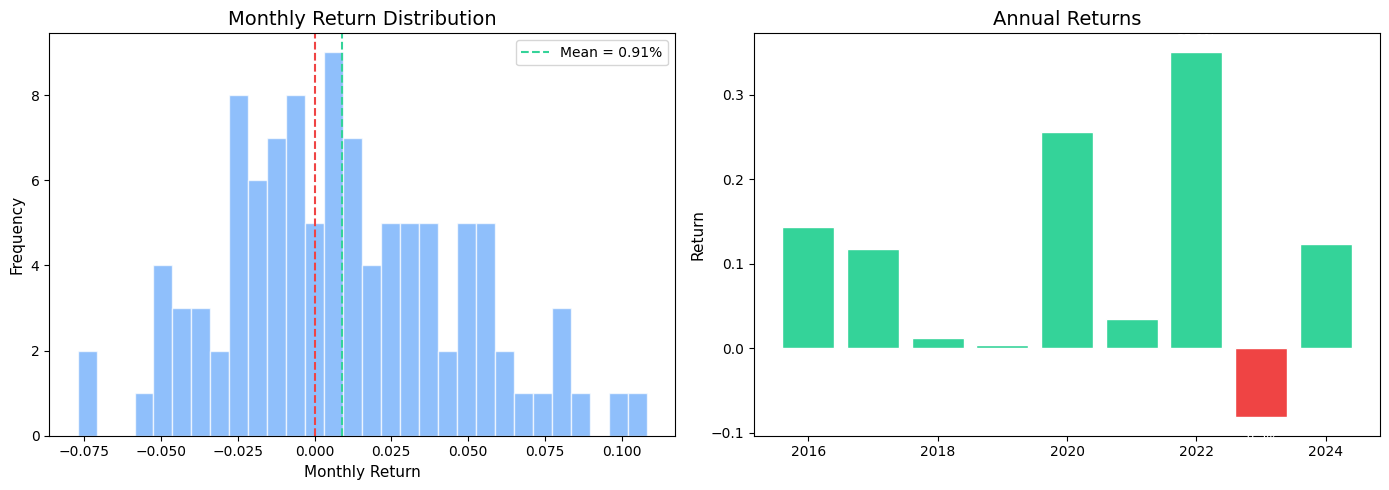

In [6]:
# 图5：月度收益分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：直方图
axes[0].hist(results["portfolio_return"], bins=30, color="#60a5fa", alpha=0.7, edgecolor="white")
axes[0].axvline(x=0, color="#ef4444", linewidth=1.5, linestyle="--")
axes[0].axvline(x=results["portfolio_return"].mean(), color="#34d399", linewidth=1.5, linestyle="--", label=f'Mean = {results["portfolio_return"].mean():.2%}')
axes[0].set_title("Monthly Return Distribution", fontsize=14)
axes[0].set_xlabel("Monthly Return", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].legend(fontsize=10)

# 右：按年汇总
annual = results["portfolio_return"].resample("YE").sum()
colors = ["#34d399" if x > 0 else "#ef4444" for x in annual.values]
axes[1].bar(annual.index.year, annual.values, color=colors, edgecolor="white")
axes[1].set_title("Annual Returns", fontsize=14)
axes[1].set_ylabel("Return", fontsize=11)
axes[1].axhline(y=0, color="white", linewidth=0.5, alpha=0.3)

# 给柱子加标签
for i, (yr, val) in enumerate(zip(annual.index.year, annual.values)):
    axes[1].text(yr, val + 0.01 if val > 0 else val - 0.03, f"{val:.1%}", ha="center", fontsize=9, color="white")

plt.tight_layout()
plt.show()